In [ ]:
import os

print(os.listdir('/content'))

['.config', 'Tomato_dataset.zip', 'sample_data']


Extract the tomato Dataset


In [ ]:
import zipfile

zip_path = "/content/Tomato_dataset.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Check the Extracted Files

In [ ]:
import os

print(os.listdir("/content/tomato_dataset"))

['tomato']


In [ ]:
import os

print(os.listdir("/content/tomato_dataset/tomato"))

['cnn_train.py', 'train', 'val']


Set the Dataset Paths

In [ ]:
train_dir = "/content/tomato_dataset/tomato/train"
val_dir = "/content/tomato_dataset/tomato/val"

print("Training path:", train_dir)
print("Validation path:", val_dir)

Training path: /content/tomato_dataset/tomato/train
Validation path: /content/tomato_dataset/tomato/val


Check the Tomato Disease Classes

In [ ]:
import os

class_folders = os.listdir(train_dir)

print("Number of classes:", len(class_folders))
print("\nClasses:")

for i, folder in enumerate(class_folders):
    print(i + 1, ":", folder)

Number of classes: 10

Classes:
1 : Tomato___Bacterial_spot
2 : Tomato___Early_blight
3 : Tomato___healthy
4 : Tomato___Late_blight
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Tomato_mosaic_virus
7 : Tomato___Septoria_leaf_spot
8 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
9 : Tomato___Target_Spot
10 : Tomato___Leaf_Mold


Count Images in Each Class

In [ ]:
import os

print("Training Dataset:")

total_train = 0

for folder in class_folders:
    folder_path = os.path.join(train_dir, folder)

    image_count = len([
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(folder, ":", image_count)

    total_train += image_count

print("\nTotal Training Images:", total_train)

Training Dataset:
Tomato___Bacterial_spot : 1000
Tomato___Early_blight : 1000
Tomato___healthy : 1000
Tomato___Late_blight : 1000
Tomato___Spider_mites Two-spotted_spider_mite : 1000
Tomato___Tomato_mosaic_virus : 1000
Tomato___Septoria_leaf_spot : 1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1000
Tomato___Target_Spot : 1000
Tomato___Leaf_Mold : 1000

Total Training Images: 10000


Count Validation Images

In [ ]:
print("Validation Dataset:")

total_val = 0

for folder in class_folders:
    folder_path = os.path.join(val_dir, folder)

    image_count = len([
        file for file in os.listdir(folder_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(folder, ":", image_count)

    total_val += image_count

print("\nTotal Validation Images:", total_val)

Validation Dataset:
Tomato___Bacterial_spot : 100
Tomato___Early_blight : 100
Tomato___healthy : 100
Tomato___Late_blight : 100
Tomato___Spider_mites Two-spotted_spider_mite : 100
Tomato___Tomato_mosaic_virus : 100
Tomato___Septoria_leaf_spot : 100
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 100
Tomato___Target_Spot : 100
Tomato___Leaf_Mold : 100

Total Validation Images: 1000


Load the Training Dataset

In [ ]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

Found 10000 files belonging to 10 classes.


Load the Validation Dataset

In [ ]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

Found 1000 files belonging to 10 classes.


Get Class Names from TensorFlow

In [ ]:
class_names = train_dataset.class_names

print("Number of Classes:", len(class_names))

print("\nClass Names:")

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of Classes: 10

Class Names:
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy


Visualize Tomato Leaf Images

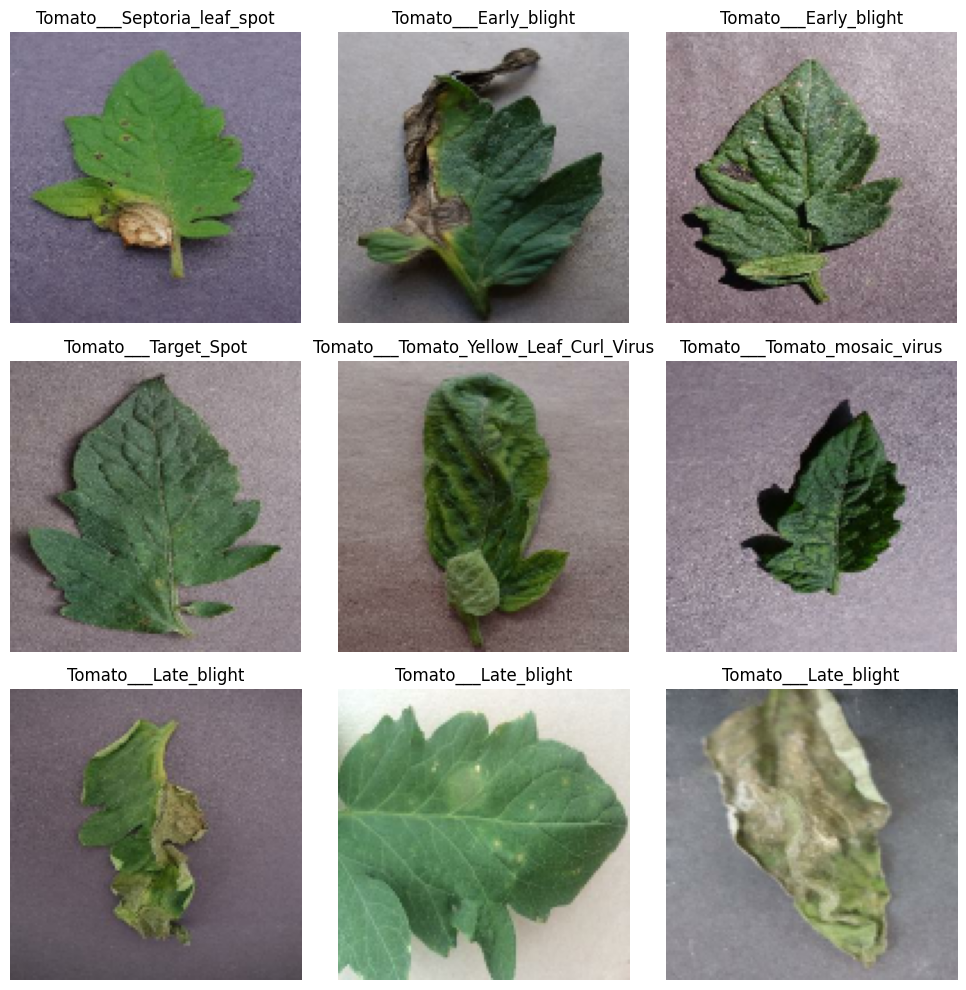

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

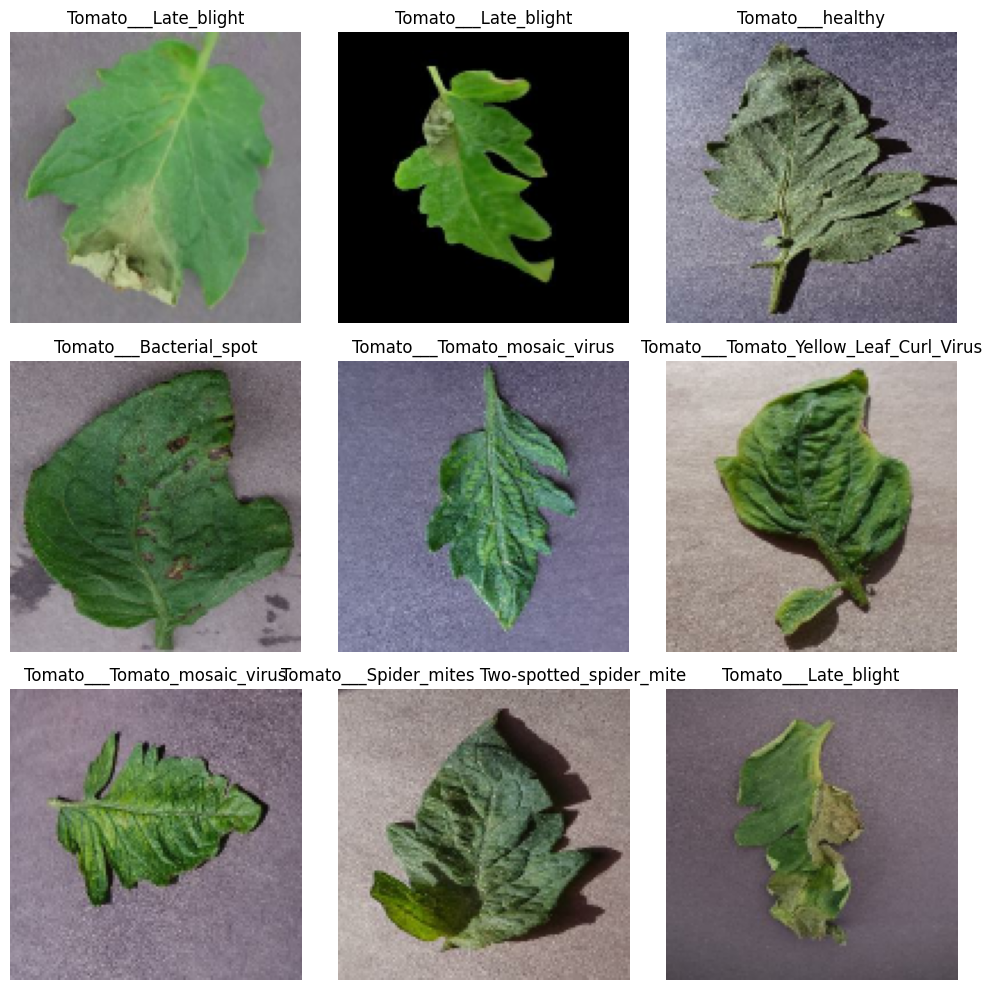

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

print("CNN libraries imported successfully!")

CNN libraries imported successfully!


Create CNN Model

In [ ]:
model = Sequential()

# Normalize pixel values from 0-255 to 0-1
model.add(
    Rescaling(
        1./255,
        input_shape=(128, 128, 3)
    )
)

# Convolution Layer 1
model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    )
)

# Max Pooling Layer 1
model.add(
    MaxPooling2D(
        (2, 2)
    )
)

# Convolution Layer 2
model.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

# Max Pooling Layer 2
model.add(
    MaxPooling2D(
        (2, 2)
    )
)

# Convolution Layer 3
model.add(
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    )
)

# Max Pooling Layer 3
model.add(
    MaxPooling2D(
        (2, 2)
    )
)

# Flatten Layer
model.add(
    Flatten()
)

# Fully Connected Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Dropout Layer
model.add(
    Dropout(0.5)
)

# Output Layer - 10 classes
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

print("CNN model created successfully!")

CNN model created successfully!


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile CNN Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


Train CNN Model

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - accuracy: 0.4719 - loss: 1.5007 - val_accuracy: 0.6180 - val_loss: 1.0244
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7040 - loss: 0.8700 - val_accuracy: 0.7800 - val_loss: 0.6644
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - accuracy: 0.7681 - loss: 0.6740 - val_accuracy: 0.7660 - val_loss: 0.7119
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.8088 - loss: 0.5607 - val_accuracy: 0.8410 - val_loss: 0.5343
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.8281 - loss: 0.4941 - val_accuracy: 0.8650 - val_loss: 0.4108
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.8594 - loss: 0.4100 - val_accuracy: 0.8560 - val_loss: 0.4336
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.8749 - loss: 0.3741 - val_accuracy: 0.8590 - val_loss: 0.4702
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.8838 - loss: 0.3495 - val_accu